Import de dataset y librerias

In [1]:
import pandas as pd
import numpy as np
from skforecast.recursive import ForecasterRecursive
import shap
import matplotlib.pyplot as plt
from skforecast.plot import set_dark_theme
from skforecast.model_selection import backtesting_forecaster, TimeSeriesFold
from sklearn.inspection import PartialDependenceDisplay
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from skforecast.model_selection import grid_search_forecaster
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

dataset = 'Lorca_processed.csv'
                              
data = pd.read_csv(
        dataset,
        sep=";",
        low_memory=False,
)

data = data.sort_index() #Ordenar por fecha

data["datetime"] = pd.to_datetime(data["datetime"], dayfirst=True, errors="coerce") #convertimos time a datatime
data["month"] = data["datetime"].dt.month
data["day"] = data["datetime"].dt.day
data["hour"] = data["datetime"].dt.hour
data["minute"] = data["datetime"].dt.minute

data.drop(columns=["datetime"], inplace=True) #eliminamos la columna Time

exogenas = ['temperature', 'solarRad', 'humedad', 'windSpeed', 'rain', 'pressure', 'pressure_sensor','month', 'day', 'hour', 'minute']


Dividimos en train y test

In [2]:
train_size = int(len(data) * 0.8)

data_train = data.iloc[:train_size]   
data_test  = data.iloc[train_size:]   

Escalamos los datos.

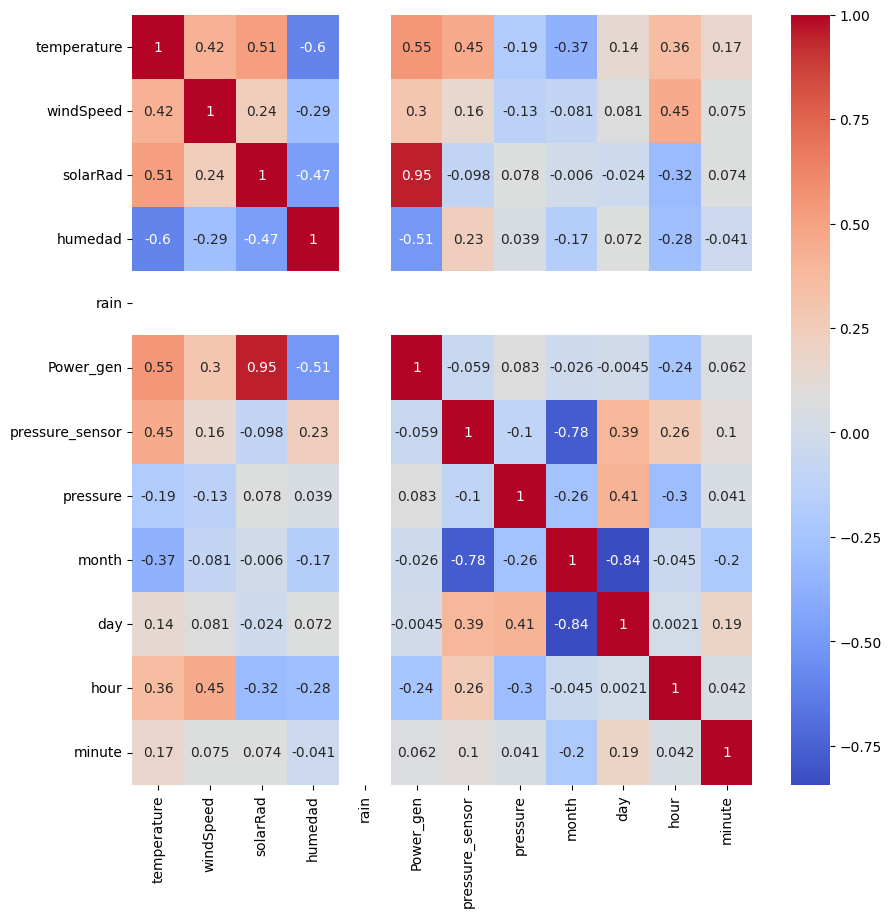

In [3]:
scaler = MinMaxScaler()
#entrenamiento
train_scaled = data_train.copy()
train_scaled[exogenas] = scaler.fit_transform(data_train[exogenas])

corr_df = train_scaled.corr(method ='spearman')

#test
test_scaled = data_test.copy()
test_scaled[exogenas] = scaler.fit_transform(data_test[exogenas])

corr_df = test_scaled.corr(method ='spearman')

plt.figure(figsize=(10, 10))
sns.heatmap(corr_df, annot=True, cmap='coolwarm')

plt.show()

Obtenemos los parámetros óptimos

In [4]:
'''parametros = {
    'learning_rate': [0.01, 0.1],
    'max_depth': [5, 9],
    'n_estimators': [200, 900],
    'subsample': [0.6, 0.8, 1.0]
}

forecaster = ForecasterRecursive(
    estimator = XGBRegressor(), 
    lags = 7
)

cv = TimeSeriesFold(
    initial_train_size = int(len(data_train) * 0.05),
    steps = 366,
    gap = 0
)

grid_search = grid_search_forecaster(
    forecaster = forecaster,
    y = data_train['Power_gen'],
    exog = data_train[exogenas],
    param_grid = parametros,
    cv=cv,
    metric = 'mean_absolute_error',
    return_best = True,
    verbose = False
)'''

"parametros = {\n    'learning_rate': [0.01, 0.1],\n    'max_depth': [5, 9],\n    'n_estimators': [200, 900],\n    'subsample': [0.6, 0.8, 1.0]\n}\n\nforecaster = ForecasterRecursive(\n    estimator = XGBRegressor(), \n    lags = 7\n)\n\ncv = TimeSeriesFold(\n    initial_train_size = int(len(data_train) * 0.05),\n    steps = 366,\n    gap = 0\n)\n\ngrid_search = grid_search_forecaster(\n    forecaster = forecaster,\n    y = data_train['Power_gen'],\n    exog = data_train[exogenas],\n    param_grid = parametros,\n    cv=cv,\n    metric = 'mean_absolute_error',\n    return_best = True,\n    verbose = False\n)"

Evolucion de las variables exogenas

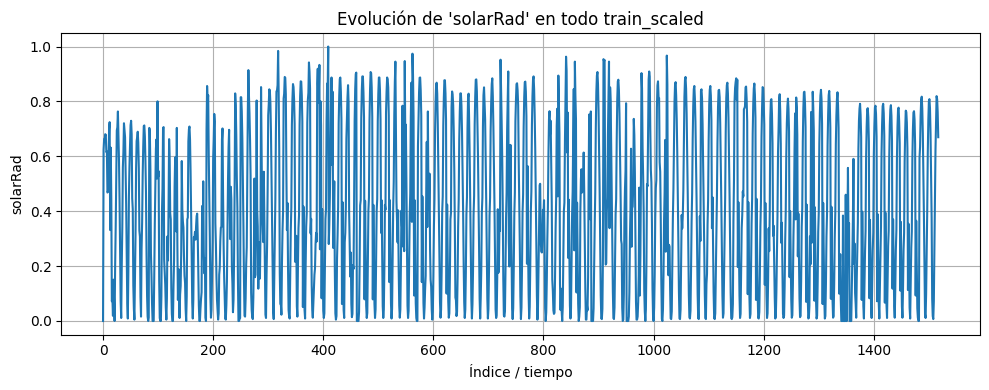

In [5]:
var = "solarRad"  #variable a analizar

plt.figure(figsize=(10, 4))
plt.plot(train_scaled.index, train_scaled[var])
plt.xlabel("Índice / tiempo")
plt.ylabel(var)
plt.title(f"Evolución de '{var}' en todo train_scaled")
plt.grid(True)
plt.tight_layout()
plt.show()


El primer paso es crear el forecaster.

In [6]:
forecaster = ForecasterRecursive(
    estimator = XGBRegressor(learning_rate = 0.01, max_depth = 5, n_estimators = 900, subsample = 0.8),
    lags = 3
)

Entrenamos el forecaster

In [7]:
forecaster.fit(y=train_scaled['Power_gen'], exog=train_scaled[exogenas])

Comprobamos si hay overfitting. El early_stop = None, por lo que se aplicará sobre los 900 árboles. La reducción del error segun avanza el train indica la efectiva eliminacion de perdidas. Alcanza unaestabilización al final, lo que significa el final del proceso de entrenamiento. El comportamiento del modelo en entrenamiento y validacion es consistente, lo que confirma la no presencia de sobreentrenamiento en los datos.

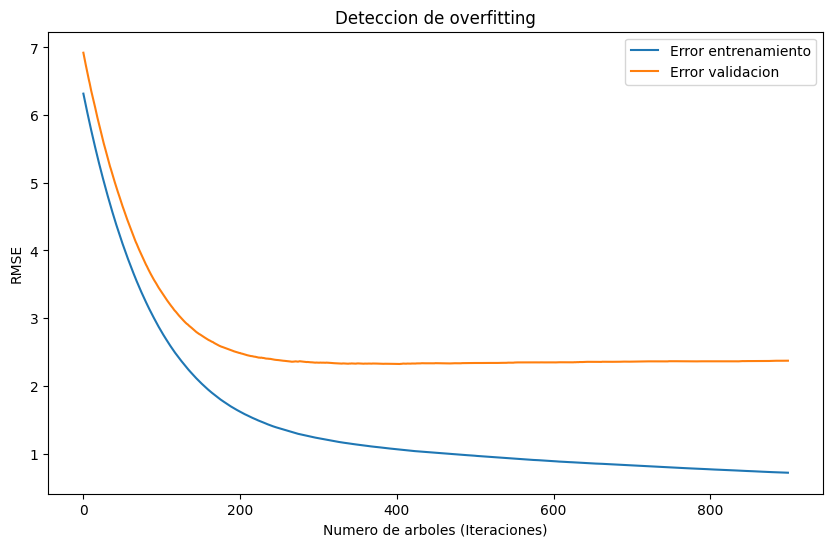

In [8]:
X_train, y_train = forecaster.create_train_X_y(y=train_scaled['Power_gen'], exog=train_scaled[exogenas])

X_test, y_test = forecaster.create_train_X_y(y=test_scaled['Power_gen'], exog=test_scaled[exogenas])

model  = forecaster.estimator

model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose = False)

results = model.evals_result()

plt.figure(figsize=(10,6))
plt.plot(results['validation_0']['rmse'], label='Error entrenamiento')
plt.plot(results['validation_1']['rmse'], label='Error validacion')
plt.xlabel('Numero de arboles (Iteraciones)')
plt.ylabel('RMSE')
plt.title('Deteccion de overfitting')
plt.legend()
plt.show()

Obtenemos las variables mas importantes en el forecaster

In [9]:
importancia = forecaster.get_feature_importances()
print(importancia)

            feature  importance
4          solarRad    0.657566
0             lag_1    0.118702
10            month    0.040820
12             hour    0.038991
1             lag_2    0.033515
3       temperature    0.019037
11              day    0.015594
2             lag_3    0.015506
13           minute    0.015199
5           humedad    0.014381
9   pressure_sensor    0.013280
8          pressure    0.008756
6         windSpeed    0.008653
7              rain    0.000000


Usamos SHAP para crear los datos de entrenamiento

In [10]:
x_train, y_train = forecaster.create_train_X_y(
    y=train_scaled['Power_gen'],
    exog=train_scaled[exogenas]
)

print(x_train.head()) 
print(y_train.head(3)) 

       lag_1      lag_2      lag_3  temperature  solarRad  humedad  windSpeed  \
3   7.674667   3.837333   0.000000     0.318436  0.662675   0.3125   0.052632   
4  11.512000   7.674667   3.837333     0.348231  0.680639   0.3000   0.157895   
5   8.634000  11.512000   7.674667     0.351955  0.678643   0.3125   0.421055   
6   5.756000   8.634000  11.512000     0.350095  0.615768   0.3250   0.421055   
7   2.878000   5.756000   8.634000     0.337059  0.617764   0.3000   0.315790   

   rain  pressure  pressure_sensor     month       day      hour    minute  
3   0.0  0.910873         0.748053  0.166667  0.133333  0.521739  0.406780  
4   0.0  0.862745         0.749157  0.166667  0.133333  0.565217  0.406780  
5   0.0  0.860963         0.749636  0.166667  0.133333  0.565217  0.491525  
6   0.0  0.855615         0.748418  0.166667  0.133333  0.565217  0.576271  
7   0.0  0.852050         0.750050  0.166667  0.133333  0.565217  0.661017  
3    11.512
4     8.634
5     5.756
Name: y, dtype:

Explainer del SHAP

In [11]:
explainer = shap.Explainer(forecaster.estimator)

#50% de los datos de entrenamiento
rng = np.random.default_rng(42)
sample_indices = rng.choice(x_train.index, size=int(len(x_train) * 0.5), replace=False)
x_train_sample = x_train.loc[sample_indices,:]
shap_values = explainer.shap_values(x_train_sample)

Grafica resumen de SHAP

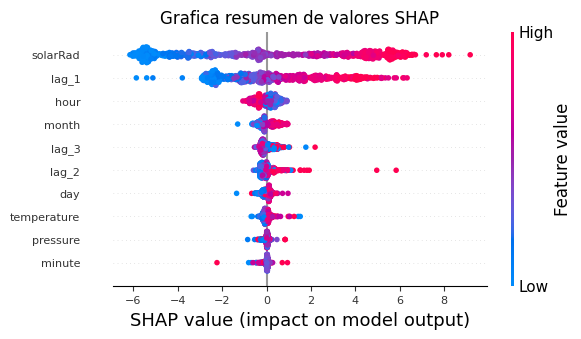

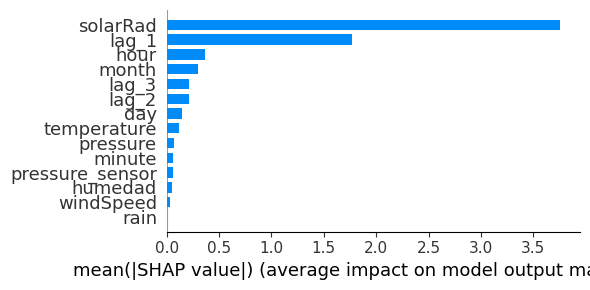

In [12]:
shap.initjs()
shap.summary_plot(shap_values, x_train_sample, max_display=10, show=False)
fig, ax = plt.gcf(), plt.gca()
ax.set_title('Grafica resumen de valores SHAP')
ax.tick_params(labelsize=8)
fig.set_size_inches(6,3)
plt.show()


plt.figure()
shap.summary_plot(shap_values, x_train, plot_type="bar", plot_size=(6, 3))
plt.show()

Grafica de dependencia

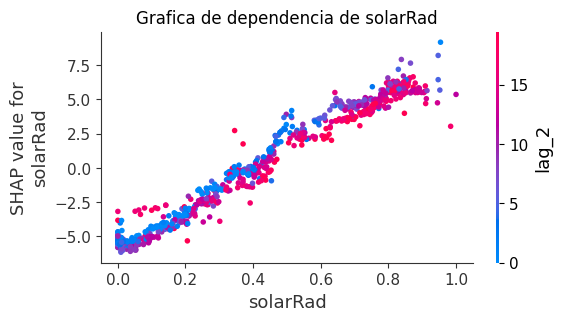

In [13]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.set_title('Grafica de dependencia de solarRad')

shap.dependence_plot("solarRad", shap_values, x_train_sample, ax=ax)
plt.show()

Ahora veremos las explicaciones de SHAP para predicciones de las proximas 366 muestras (data_test)

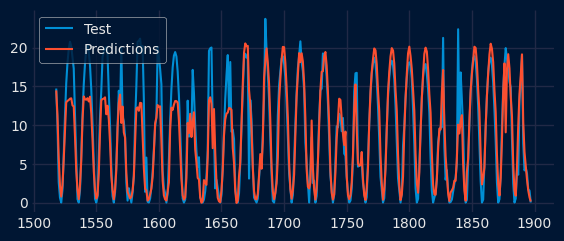

In [14]:
pred = forecaster.predict(steps=len(test_scaled), exog=test_scaled[exogenas])
set_dark_theme()
fig, ax = plt.subplots(figsize=(6, 2.5))
test_scaled['Power_gen'].plot(ax=ax, label='Test')
pred.plot(ax=ax, label='Predictions', linestyle='-')
ax.set_xlabel(None)
ax.legend()
plt.show()

Graficas de dependencia parcial.

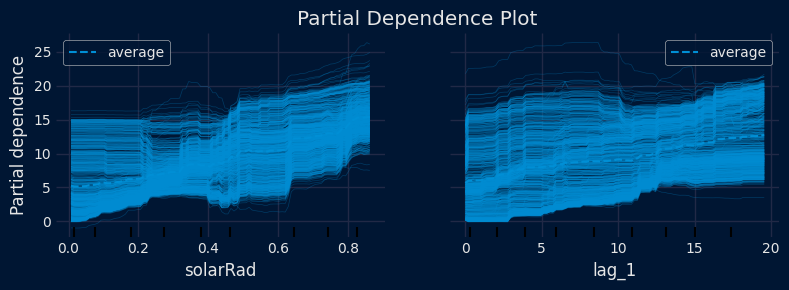

In [15]:
fig, ax = plt.subplots(figsize=(8, 3))
pd.plots = PartialDependenceDisplay.from_estimator(
    estimator = forecaster.estimator,
    X         = x_train,
    features  = ["solarRad", "lag_1"],
    kind      = 'both',
    ax        = ax,
)
ax.set_title("Partial Dependence Plot")
fig.tight_layout()
plt.show()

Metricas de la prediccion

In [16]:
y_test = test_scaled['Power_gen'].iloc[:len(pred)]

mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Coeficiente de determinación (R^2): {r2:.4f}")

Mean Absolute Error (MAE): 2.0158
Mean Squared Error (MSE): 8.9582
Root Mean Squared Error (RMSE): 2.9930
Coeficiente de determinación (R^2): 0.8150


Añadimos una variable extra, la irrandiancia ideal, de forma que ayude al modelo a saber hasta que valor podría llegar a ascender.

In [17]:
t_min = data["hour"] * 60 + data["minute"]
t_day = 24 * 60

t_mid = 13 * 60   
x = abs((t_min - t_mid) / (t_day / 2))   

irr_ideal_norm = np.clip(1 - x**2, 0, 1) 

IRR_MAX = 1002 #maxima solarRad en el dataset 
train_scaled["irr_ideal"] = IRR_MAX * irr_ideal_norm
test_scaled["irr_ideal"] = IRR_MAX * irr_ideal_norm

In [18]:
exogenas = ['temperature', 'solarRad', 'humedad', 'windSpeed',
            'rain', 'pressure', 'pressure_sensor', 'month', 'day', 'hour', 'minute',
            'irr_ideal']

forecaster.fit(y=train_scaled["Power_gen"],
               exog=train_scaled[exogenas])

pred = forecaster.predict(steps=len(test_scaled),
                          exog=test_scaled[exogenas])

Nuevas métricas de la predicción, ligeramente mejores.

In [19]:
y_test = test_scaled['Power_gen'].iloc[:len(pred)]

mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Coeficiente de determinación (R^2): {r2:.4f}")

Mean Absolute Error (MAE): 1.8457
Mean Squared Error (MSE): 8.3415
Root Mean Squared Error (RMSE): 2.8882
Coeficiente de determinación (R^2): 0.8277


Comparativa realidad vs prediccion

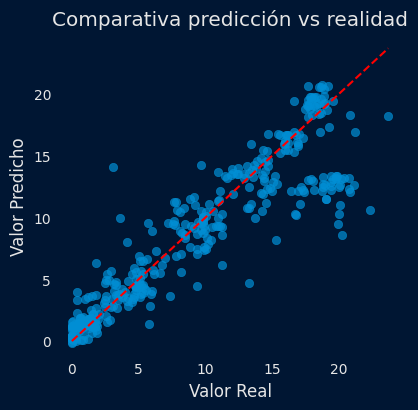

In [20]:
plt.figure(figsize=(4, 4))
plt.scatter(y_test, pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  #linea de igualdad
plt.xlabel('Valor Real')
plt.ylabel('Valor Predicho')
plt.title('Comparativa predicción vs realidad')
plt.grid()
plt.show()

Tratamiento de ceros

In [23]:
error_cero = np.where((y_test == 0) & (pred > mae))[0]

print(f"Se encontraron {len(error_cero)} errores en el valor cero")

print(pred.iloc[error_cero])
#pred.iloc[error_cero] = 0

Se encontraron 0 errores en el valor cero
Series([], Name: pred, dtype: float64)
